# RetailPulse – Data Cleaning, Merging & EDA
**Zidio Development | Data Science & Analytics Internship**

This notebook covers:
1. Loading & merging both datasets
2. Data cleaning (duplicates, cancellations, nulls, bad values)
3. Feature engineering (TotalPrice, datetime features, RFM)
4. Full EDA with visualizations
5. Saving the final clean dataset for the team

**Source datasets:**
- `Online_Retail.xlsx` → same as Dataset II Sheet 2 (redundant, excluded)
- `online_retail_II.xlsx` → Sheet 1 (2009–2010) + Sheet 2 (2010–2011) → **used as master source**

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid', palette='muted')

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Merge Datasets

In [2]:
# Load both sheets from Dataset II
print('Loading Year 2009-2010...')
df_2009 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')

print('Loading Year 2010-2011...')
df_2010 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

print(f'Sheet 1 shape: {df_2009.shape}')
print(f'Sheet 2 shape: {df_2010.shape}')

Loading Year 2009-2010...
Loading Year 2010-2011...
Sheet 1 shape: (525461, 8)
Sheet 2 shape: (541910, 8)


In [3]:
# WHY we skip Online_Retail.xlsx:
# It covers Dec 2010 - Dec 2011, identical to Dataset II Sheet 2.
# Merging it would double-count that period.
# Dataset II alone gives us the full 2009-2011 range.

# Standardise column names (Sheet 1 & 2 use same names, just confirming)
rename_map = {
    'Invoice': 'InvoiceNo',
    'Price': 'UnitPrice',
    'Customer ID': 'CustomerID'
}
df_2009.rename(columns=rename_map, inplace=True)
df_2010.rename(columns=rename_map, inplace=True)

# Merge
df = pd.concat([df_2009, df_2010], ignore_index=True)
print(f'Combined shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Date range: {df["InvoiceDate"].min()} → {df["InvoiceDate"].max()}')

Combined shape: (1067371, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


In [4]:
# Quick peek
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


## 2. Initial Data Assessment

In [5]:
print('=== SHAPE ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== DTYPES ===')
print(df.dtypes)

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing': missing, 'Pct%': missing_pct}))

print('\n=== DUPLICATES ===')
print(f'Duplicate rows: {df.duplicated().sum():,}')

=== SHAPE ===
Rows: 1,067,371  |  Columns: 8

=== DTYPES ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

=== MISSING VALUES ===
             Missing   Pct%
InvoiceNo          0   0.00
StockCode          0   0.00
Description     4382   0.41
Quantity           0   0.00
InvoiceDate        0   0.00
UnitPrice          0   0.00
CustomerID    243007  22.77
Country            0   0.00

=== DUPLICATES ===
Duplicate rows: 34,335


In [6]:
# Check cancellations and negative values
cancellations = df['InvoiceNo'].astype(str).str.startswith('C').sum()
neg_qty = (df['Quantity'] <= 0).sum()
bad_price = (df['UnitPrice'] <= 0).sum()

print(f'Cancellation rows (Invoice starts with C): {cancellations:,}')
print(f'Negative/zero Quantity rows:               {neg_qty:,}')
print(f'Zero/negative UnitPrice rows:              {bad_price:,}')

Cancellation rows (Invoice starts with C): 19,494
Negative/zero Quantity rows:               22,950
Zero/negative UnitPrice rows:              6,207


## 3. Data Cleaning Pipeline

In [7]:
raw_count = len(df)
cleaning_log = []

# Step 1: Remove duplicate rows
df = df.drop_duplicates()
cleaning_log.append(('Duplicates removed', raw_count - len(df)))

# Step 2: Remove cancellations
before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
cleaning_log.append(('Cancellations removed', before - len(df)))

# Step 3: Remove zero/negative quantities
before = len(df)
df = df[df['Quantity'] > 0]
cleaning_log.append(('Zero/negative Quantity removed', before - len(df)))

# Step 4: Remove zero/negative unit prices
before = len(df)
df = df[df['UnitPrice'] > 0]
cleaning_log.append(('Zero/negative UnitPrice removed', before - len(df)))

# Step 5: Drop rows with no CustomerID (can't do RFM/Churn without it)
before = len(df)
df = df.dropna(subset=['CustomerID'])
cleaning_log.append(('Missing CustomerID removed', before - len(df)))

# Step 6: Fill missing Description
df = df.assign(Description=df['Description'].fillna('Unknown'))
cleaning_log.append(('Description nulls filled', df['Description'].eq('Unknown').sum()))

# Step 7: Fix dtypes
df = df.assign(
    CustomerID=df['CustomerID'].astype(int),
    InvoiceNo=df['InvoiceNo'].astype(str),
    StockCode=df['StockCode'].astype(str),
    InvoiceDate=pd.to_datetime(df['InvoiceDate'])
)

# Step 8: Strip whitespace from string columns
df = df.assign(
    Description=df['Description'].str.strip(),
    StockCode=df['StockCode'].str.strip(),
    Country=df['Country'].str.strip()
)


# Step 9: Remove non-product descriptions (junk entries)
before = len(df)
junk_descriptions = ['MANUAL', 'POSTAGE', 'DOTCOM POSTAGE', 'BANK CHARGES', 'DISCOUNT']
df = df[~df['Description'].str.upper().isin(junk_descriptions)]
cleaning_log.append(('Junk descriptions removed', before - len(df)))

# Step 10: Cap outliers at 99th percentile (keeps data, removes extreme skew)
q99_qty   = df['Quantity'].quantile(0.99)
q99_price = df['UnitPrice'].quantile(0.99)
df['Quantity']   = df['Quantity'].clip(upper=q99_qty)
df['UnitPrice']  = df['UnitPrice'].clip(upper=q99_price)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
cleaning_log.append(('Outliers capped (99th pct)', 0))  # no rows removed, just capped

# Cleaning Summary
print('=== CLEANING SUMMARY ===')
for step, count in cleaning_log:
    print(f'  {step}: {count:,}')
print(f'\nRaw rows:   {raw_count:,}')
print(f'Clean rows: {len(df):,}')
print(f'Rows kept:  {len(df)/raw_count*100:.1f}%')

=== CLEANING SUMMARY ===
  Duplicates removed: 34,335
  Cancellations removed: 19,104
  Zero/negative Quantity removed: 3,393
  Zero/negative UnitPrice removed: 2,626
  Missing CustomerID removed: 228,488
  Description nulls filled: 0

Raw rows:   1,067,371
Clean rows: 779,425
Rows kept:  73.0%


## 4. Feature Engineering

In [8]:
# Revenue feature
df = df.assign(TotalPrice=df['Quantity'] * df['UnitPrice'])

# Datetime features
df = df.assign(
    Year=df['InvoiceDate'].dt.year,
    Month=df['InvoiceDate'].dt.month,
    MonthName=df['InvoiceDate'].dt.strftime('%b'),
    DayOfWeek=df['InvoiceDate'].dt.dayofweek,       # 0=Monday
    DayName=df['InvoiceDate'].dt.strftime('%A'),
    Hour=df['InvoiceDate'].dt.hour,
    Quarter=df['InvoiceDate'].dt.quarter,
    YearMonth=df['InvoiceDate'].dt.to_period('M')
)

print('Feature engineering complete.')
print(f'Final columns: {df.columns.tolist()}')
df.head(3)

Feature engineering complete.
Final columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month', 'MonthName', 'DayOfWeek', 'DayName', 'Hour', 'Quarter', 'YearMonth']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,MonthName,DayOfWeek,DayName,Hour,Quarter,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,Dec,1,Tuesday,7,4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Dec,1,Tuesday,7,4,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Dec,1,Tuesday,7,4,2009-12


In [9]:
# RFM Feature Table (used by Churn + Segmentation modules)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

# RFM Scores (1-5 scale, 5 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Segment labels
def rfm_segment(row):
    if row['RFM_Total'] >= 13:
        return 'Champions'
    elif row['RFM_Total'] >= 10:
        return 'Loyal Customers'
    elif row['RFM_Total'] >= 7:
        return 'Potential Loyalists'
    elif row['R_Score'] >= 4:
        return 'New Customers'
    elif row['R_Score'] >= 2:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

print(f'RFM table shape: {rfm.shape}')
print('\nSegment distribution:')
print(rfm['Segment'].value_counts())
rfm.head()

RFM table shape: (5878, 10)

Segment distribution:
Segment
Potential Loyalists    1453
Loyal Customers        1357
Champions              1295
Lost                    946
At Risk                 757
New Customers            70
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,12346,326,12,77556.46,2,5,5,255,12,Loyal Customers
1,12347,2,8,4921.53,5,4,5,545,14,Champions
2,12348,75,5,2019.40,3,4,4,344,11,Loyal Customers
3,12349,19,4,4428.69,5,3,5,535,13,Champions
4,12350,310,1,334.40,2,1,2,212,5,At Risk


## 5. Exploratory Data Analysis (EDA)

In [10]:
# 5.1 Dataset Summary Stats
print('=== FINAL DATASET SUMMARY ===')
print(f'Total transactions:   {len(df):,}')
print(f'Unique invoices:      {df["InvoiceNo"].nunique():,}')
print(f'Unique customers:     {df["CustomerID"].nunique():,}')
print(f'Unique products:      {df["StockCode"].nunique():,}')
print(f'Countries:            {df["Country"].nunique()}')
print(f'Date range:           {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}')
print(f'Total revenue:        £{df["TotalPrice"].sum():,.2f}')
print(f'Avg order value:      £{df.groupby("InvoiceNo")["TotalPrice"].sum().mean():,.2f}')

=== FINAL DATASET SUMMARY ===
Total transactions:   779,425
Unique invoices:      36,969
Unique customers:     5,878
Unique products:      4,631
Countries:            41
Date range:           2009-12-01 to 2011-12-09
Total revenue:        £17,374,804.27
Avg order value:      £469.98


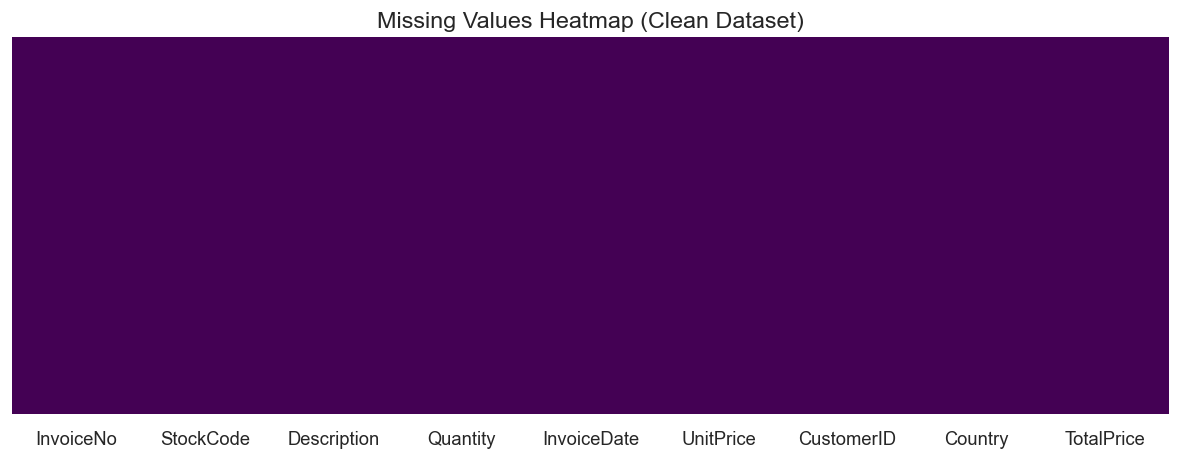

In [11]:
# 5.2 Missing Values Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df[['InvoiceNo','StockCode','Description','Quantity',
               'InvoiceDate','UnitPrice','CustomerID','Country','TotalPrice']]
            .isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (Clean Dataset)', fontsize=14)
plt.tight_layout()
plt.savefig('eda_missing_values.png', bbox_inches='tight')
plt.show()

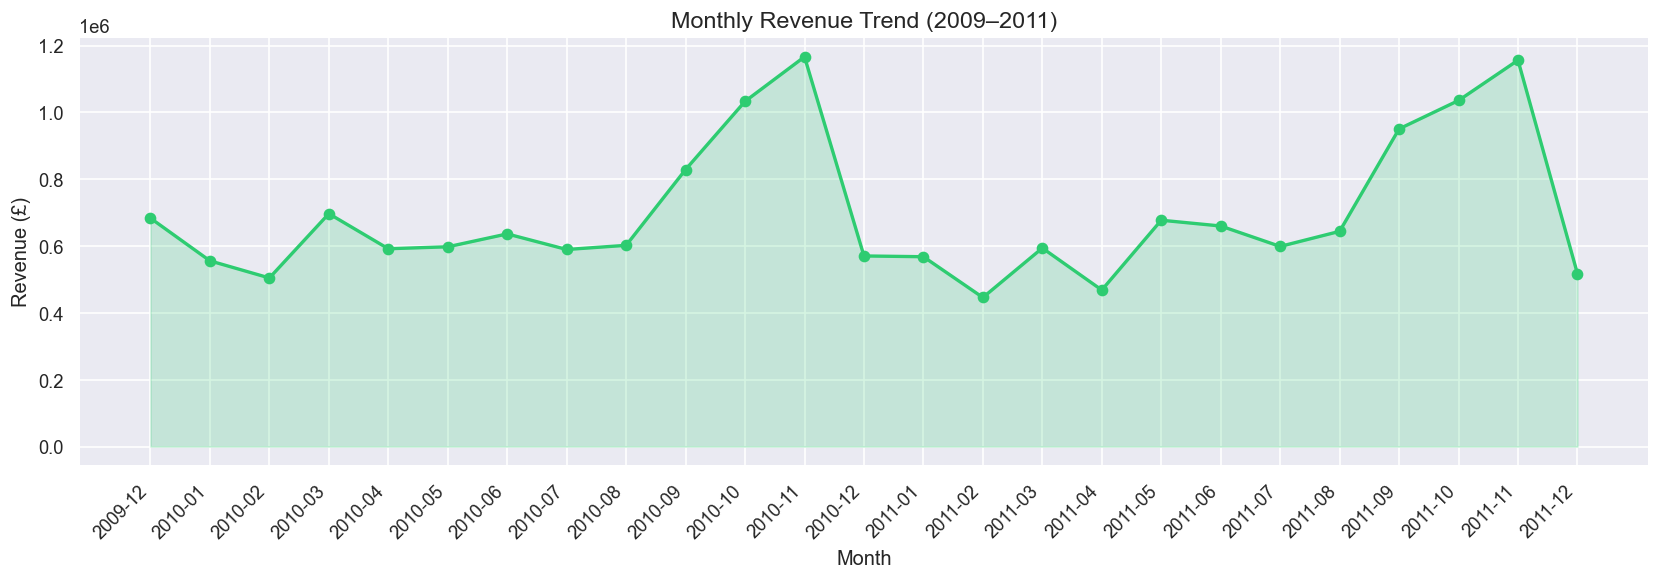

In [12]:
# 5.3 Monthly Revenue Trend
monthly_rev = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_rev['YearMonth_str'] = monthly_rev['YearMonth'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_rev['YearMonth_str'], monthly_rev['TotalPrice'], marker='o', linewidth=2, color='#2ecc71')
plt.fill_between(monthly_rev['YearMonth_str'], monthly_rev['TotalPrice'], alpha=0.2, color='#2ecc71')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue Trend (2009–2011)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('eda_monthly_revenue.png', bbox_inches='tight')
plt.show()

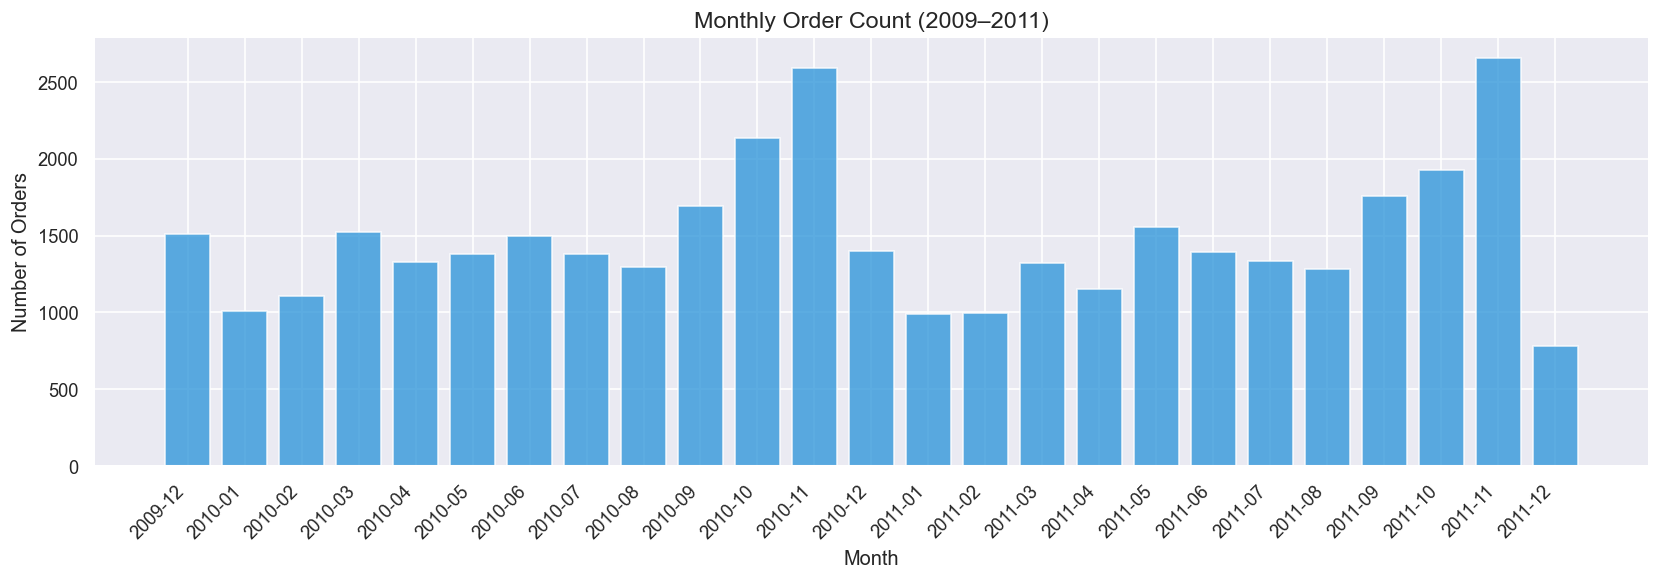

In [13]:
# 5.4 Monthly Transaction Count
monthly_orders = df.groupby('YearMonth')['InvoiceNo'].nunique().reset_index()
monthly_orders['YearMonth_str'] = monthly_orders['YearMonth'].astype(str)

plt.figure(figsize=(14, 5))
plt.bar(monthly_orders['YearMonth_str'], monthly_orders['InvoiceNo'], color='#3498db', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Order Count (2009–2011)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('eda_monthly_orders.png', bbox_inches='tight')
plt.show()

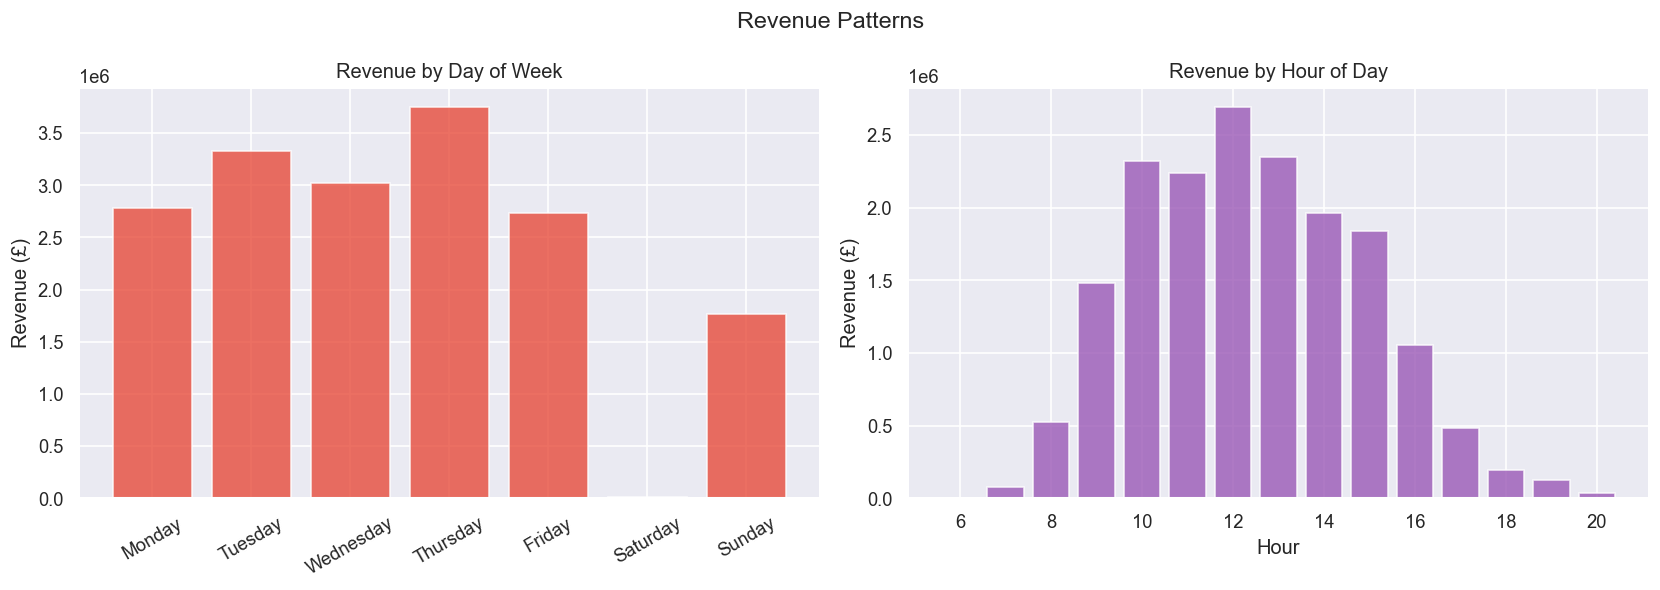

In [14]:
# 5.5 Revenue by Day of Week and Hour
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = df.groupby('DayName')['TotalPrice'].sum().reindex(day_order)
axes[0].bar(dow_rev.index, dow_rev.values, color='#e74c3c', alpha=0.8)
axes[0].set_title('Revenue by Day of Week')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=30)

# Hour of day
hour_rev = df.groupby('Hour')['TotalPrice'].sum()
axes[1].bar(hour_rev.index, hour_rev.values, color='#9b59b6', alpha=0.8)
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Revenue (£)')

plt.suptitle('Revenue Patterns', fontsize=14)
plt.tight_layout()
plt.savefig('eda_revenue_patterns.png', bbox_inches='tight')
plt.show()

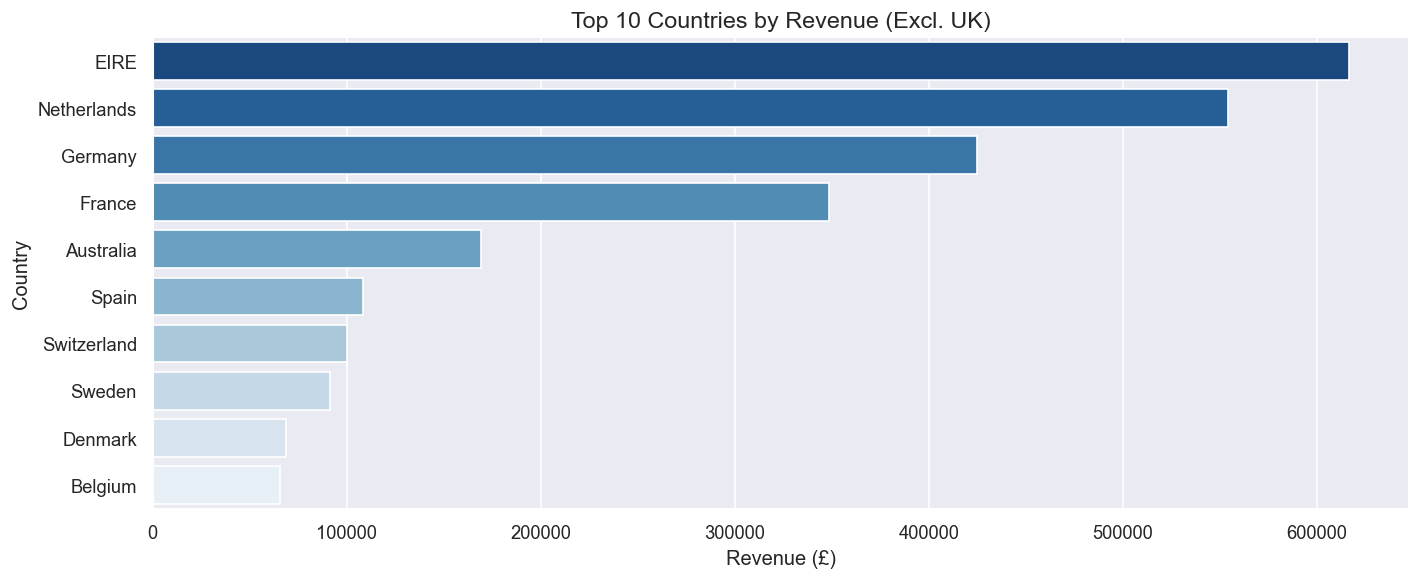

In [15]:
# 5.6 Top 10 Countries by Revenue (excluding UK)
country_rev = df[df['Country'] != 'United Kingdom'].groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=country_rev.values, y=country_rev.index, palette='Blues_r')
plt.title('Top 10 Countries by Revenue (Excl. UK)', fontsize=14)
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.savefig('eda_top_countries.png', bbox_inches='tight')
plt.show()

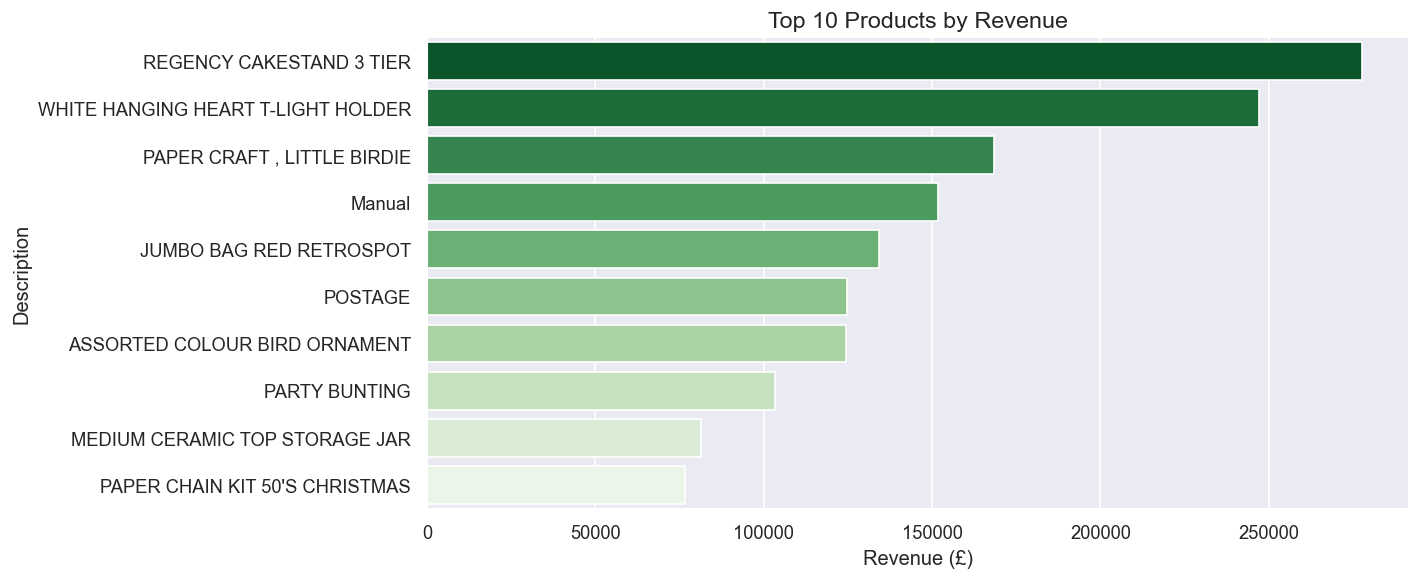

In [16]:
# 5.7 Top 10 Products by Revenue
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_products.values, y=top_products.index, palette='Greens_r')
plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.savefig('eda_top_products.png', bbox_inches='tight')
plt.show()

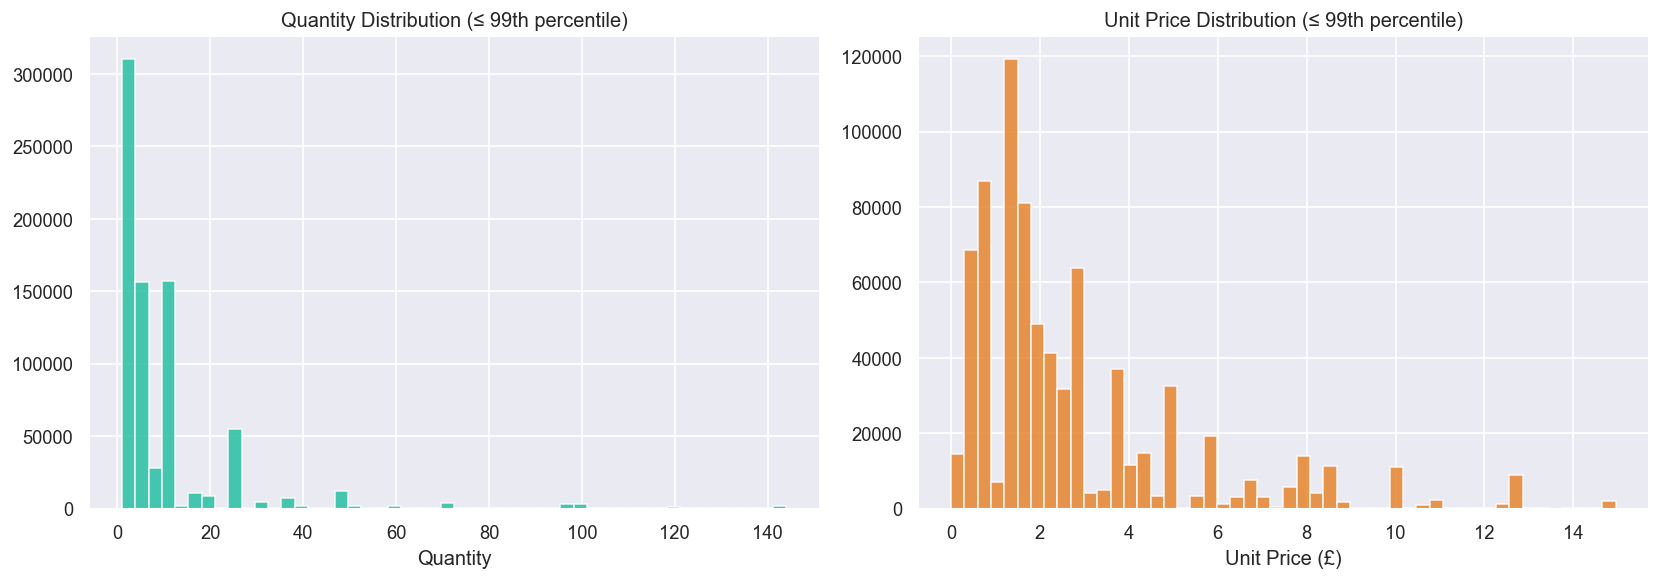

In [17]:
# 5.8 Distribution of Quantity and UnitPrice (capped at 99th percentile)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q99_qty = df['Quantity'].quantile(0.99)
q99_price = df['UnitPrice'].quantile(0.99)

df[df['Quantity'] <= q99_qty]['Quantity'].hist(bins=50, ax=axes[0], color='#1abc9c', alpha=0.8)
axes[0].set_title('Quantity Distribution (≤ 99th percentile)')
axes[0].set_xlabel('Quantity')

df[df['UnitPrice'] <= q99_price]['UnitPrice'].hist(bins=50, ax=axes[1], color='#e67e22', alpha=0.8)
axes[1].set_title('Unit Price Distribution (≤ 99th percentile)')
axes[1].set_xlabel('Unit Price (£)')

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()

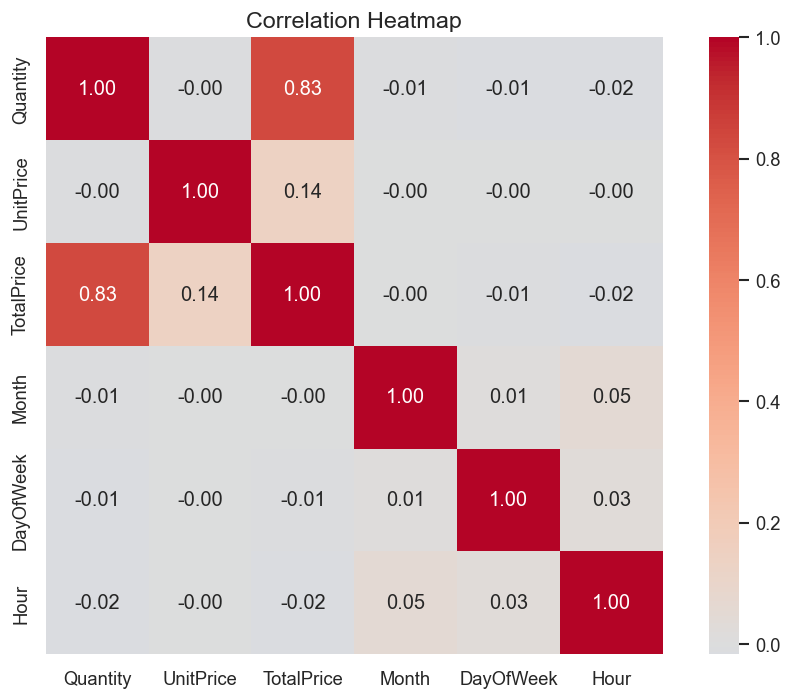

In [18]:
# 5.9 Correlation Heatmap
corr_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'Month', 'DayOfWeek', 'Hour']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

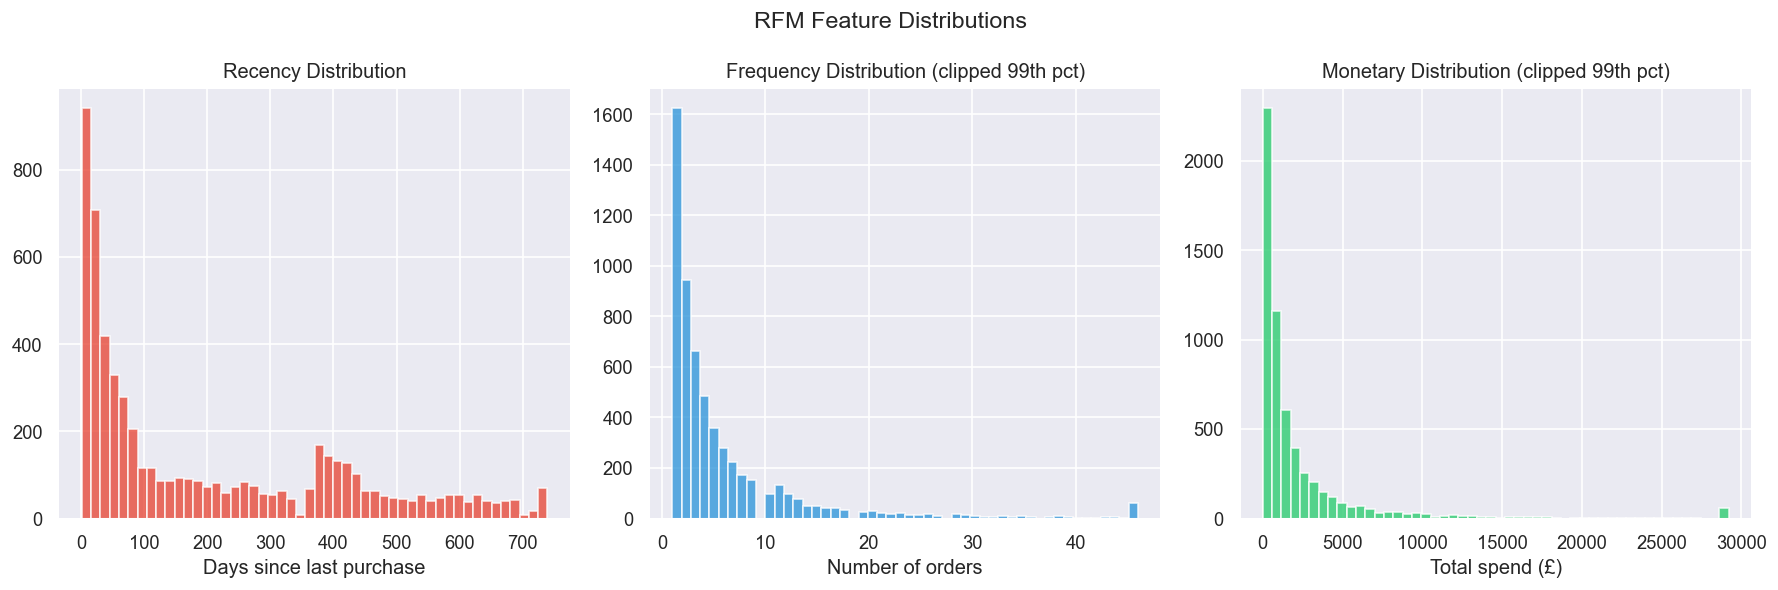

In [19]:
# 5.10 RFM Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rfm['Recency'].hist(bins=50, ax=axes[0], color='#e74c3c', alpha=0.8)
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')

rfm['Frequency'].clip(upper=rfm['Frequency'].quantile(0.99)).hist(bins=50, ax=axes[1], color='#3498db', alpha=0.8)
axes[1].set_title('Frequency Distribution (clipped 99th pct)')
axes[1].set_xlabel('Number of orders')

rfm['Monetary'].clip(upper=rfm['Monetary'].quantile(0.99)).hist(bins=50, ax=axes[2], color='#2ecc71', alpha=0.8)
axes[2].set_title('Monetary Distribution (clipped 99th pct)')
axes[2].set_xlabel('Total spend (£)')

plt.suptitle('RFM Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('eda_rfm_distributions.png', bbox_inches='tight')
plt.show()

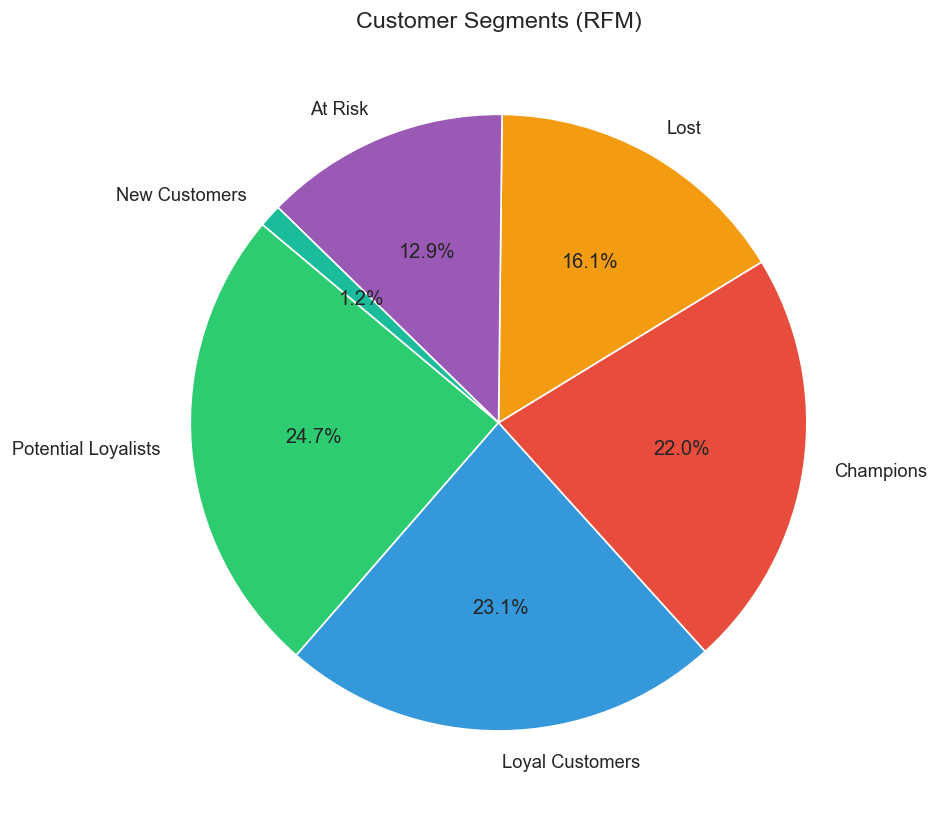

Segment
Potential Loyalists    1453
Loyal Customers        1357
Champions              1295
Lost                    946
At Risk                 757
New Customers            70
Name: count, dtype: int64


In [20]:
# 5.11 Customer Segment Pie Chart
seg_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6','#1abc9c']

plt.figure(figsize=(9, 7))
plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Customer Segments (RFM)', fontsize=14)
plt.tight_layout()
plt.savefig('eda_rfm_segments.png', bbox_inches='tight')
plt.show()
print(seg_counts)

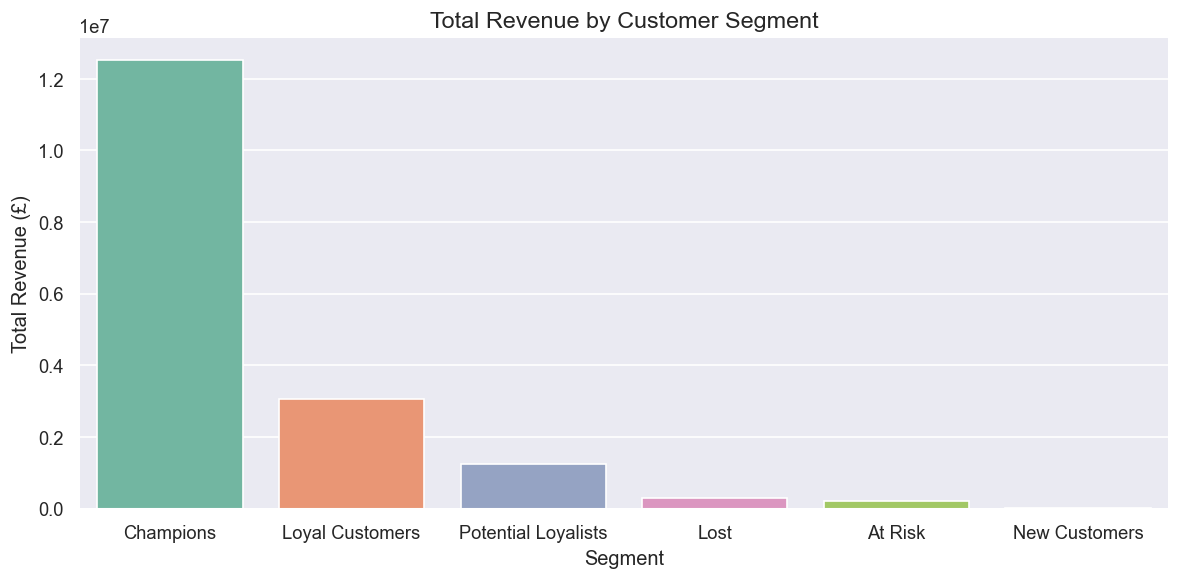

In [21]:
# 5.12 Revenue by Segment
seg_rev = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=seg_rev.index, y=seg_rev.values, palette='Set2')
plt.title('Total Revenue by Customer Segment', fontsize=14)
plt.ylabel('Total Revenue (£)')
plt.xlabel('Segment')
plt.tight_layout()
plt.savefig('eda_segment_revenue.png', bbox_inches='tight')
plt.show()

## 6. Save Clean Datasets

In [22]:
# Save main transactions table (drop Period type for CSV compatibility)
df_save = df.drop(columns=['YearMonth'])
df_save.to_csv('retailpulse_clean.csv', index=False)

# Save RFM table
rfm.to_csv('retailpulse_rfm.csv', index=False)

print('Files saved:')
print('  retailpulse_clean.csv  →  main transactions (team-wide use)')
print('  retailpulse_rfm.csv    →  RFM + segments (churn/segmentation modules)')
print(f'\nFinal dataset: {len(df_save):,} rows × {len(df_save.columns)} columns')
print(f'RFM table:     {len(rfm):,} customers')

Files saved:
  retailpulse_clean.csv  →  main transactions (team-wide use)
  retailpulse_rfm.csv    →  RFM + segments (churn/segmentation modules)

Final dataset: 779,425 rows × 16 columns
RFM table:     5,878 customers


In [23]:
# Final schema summary for the team
print('=== retailpulse_clean.csv SCHEMA ===')
for col in df_save.columns:
    print(f'  {col:<15} {str(df_save[col].dtype):<12} example: {df_save[col].iloc[0]}')

print('\n=== retailpulse_rfm.csv SCHEMA ===')
for col in rfm.columns:
    print(f'  {col:<15} {str(rfm[col].dtype):<12} example: {rfm[col].iloc[0]}')

=== retailpulse_clean.csv SCHEMA ===
  InvoiceNo       str          example: 489434
  StockCode       str          example: 85048
  Description     object       example: 15CM CHRISTMAS GLASS BALL 20 LIGHTS
  Quantity        int64        example: 12
  InvoiceDate     datetime64[us] example: 2009-12-01 07:45:00
  UnitPrice       float64      example: 6.95
  CustomerID      int64        example: 13085
  Country         str          example: United Kingdom
  TotalPrice      float64      example: 83.4
  Year            int32        example: 2009
  Month           int32        example: 12
  MonthName       str          example: Dec
  DayOfWeek       int32        example: 1
  DayName         str          example: Tuesday
  Hour            int32        example: 7
  Quarter         int32        example: 4

=== retailpulse_rfm.csv SCHEMA ===
  CustomerID      int64        example: 12346
  Recency         int64        example: 326
  Frequency       int64        example: 12
  Monetary        float